# Credit Card Fraud Detection

## Objective
The goal of this project is to build a machine learning model that can detect fraudulent credit card transactions.

This project follows the CRISP-DM methodology.

In [17]:

# Import basic libraries
import pandas as pd
import numpy as np

print("Project setup complete")

Project setup complete


## Next Steps
- Load dataset
- Perform exploratory data analysis (EDA)
- Prepare data for modeling
- Train machine learning models
- Evaluate performance

In [3]:
# Load dataset
df = pd.read_csv("creditcard.csv")

# Show first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
# Count values in target variable
df['Class'].value_counts()

Class
0.0    67264
1.0      169
Name: count, dtype: int64

In [5]:
# Percentage distribution
df['Class'].value_counts(normalize=True)

Class
0.0    0.997494
1.0    0.002506
Name: proportion, dtype: float64

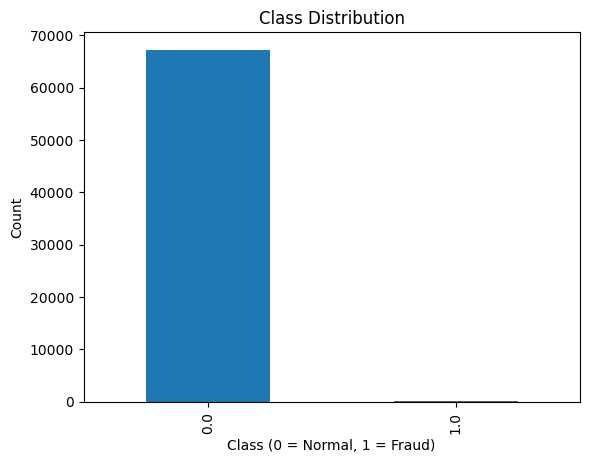

In [7]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

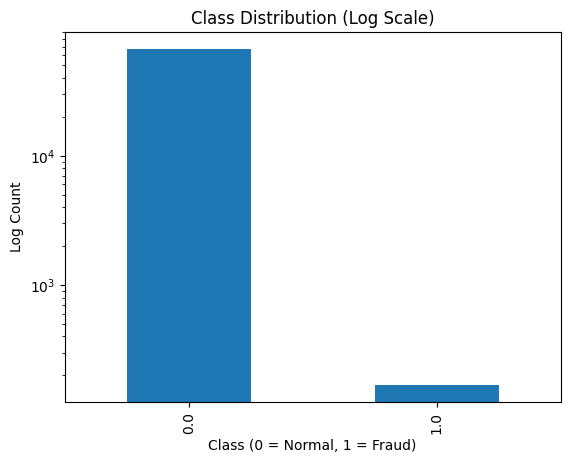

In [8]:
df['Class'].value_counts().plot(kind='bar', logy=True)
plt.title("Class Distribution (Log Scale)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Log Count")
plt.show()

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,...,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000
mean,33976.974835,-0.241622,-0.018321,0.683462,0.169473,-0.268578,0.101759,-0.114429,0.057624,0.030096,...,-0.028557,-0.106489,-0.038823,0.005627,0.136606,0.020725,0.002811,0.003520,96.628136,0.002506
std,14222.001116,1.857614,1.649726,1.418358,1.377279,1.385175,1.305232,1.251274,1.230082,1.167011,...,0.738014,0.639314,0.608941,0.596550,0.439152,0.497668,0.382484,0.322323,269.895189,0.049999
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-26.751119,-2.836627,-7.495741,-2.534330,-8.567638,-9.617915,0.000000,0.000000
25%,28238.000000,-1.001783,-0.590074,0.195636,-0.724684,-0.887468,-0.636482,-0.604414,-0.141812,-0.666519,...,-0.226694,-0.526921,-0.179448,-0.325986,-0.127251,-0.329217,-0.062635,-0.005865,7.680000,0.000000
50%,37354.000000,-0.241551,0.072585,0.772156,0.188286,-0.301379,-0.149794,-0.074146,0.066101,-0.063081,...,-0.061471,-0.081004,-0.051721,0.061460,0.174488,-0.075903,0.009512,0.022750,26.310000,0.000000
75%,44551.000000,1.153782,0.728136,1.405294,1.053095,0.269637,0.494996,0.420850,0.343556,0.688096,...,0.115486,0.309548,0.078955,0.403106,0.422752,0.297957,0.082538,0.075882,88.500000,0.000000
max,52534.000000,1.960497,18.183626,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,10.503090,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,19656.530000,1.000000


In [10]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,67264.0,96.632489,270.008302,0.0,7.68,26.38,88.36,19656.53
1.0,169.0,94.895680,220.959331,0.0,1.00,7.61,99.99,1809.68


Fraudulent transactions tend to involve smaller amounts compared to normal transactions, suggesting that fraudsters may try to avoid detection by keeping transaction values relatively low.

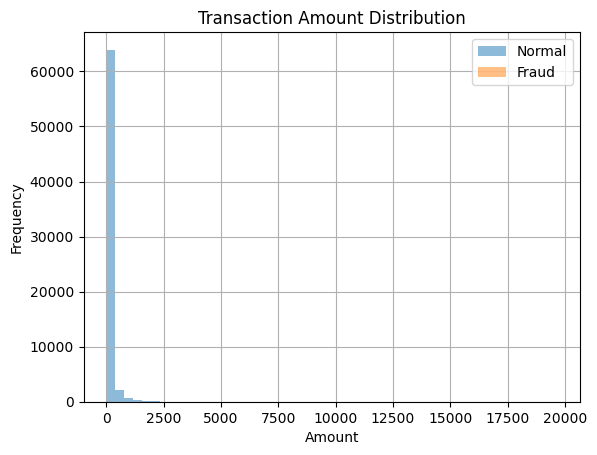

In [11]:
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.5, label='Normal')
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.5, label='Fraud')

plt.legend()
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [12]:
import numpy as np

# Create log-transformed Amount
df['LogAmount'] = np.log1p(df['Amount'])

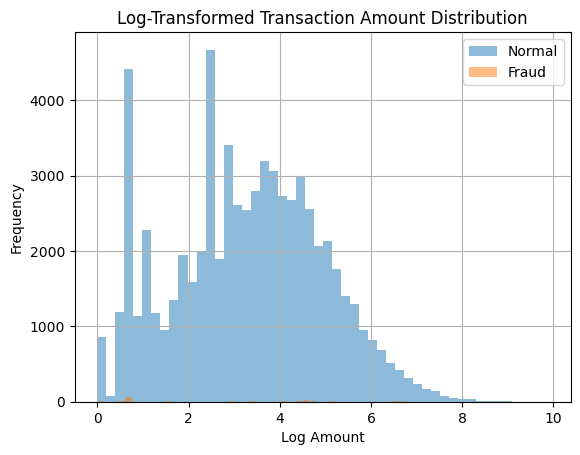

In [13]:
df[df['Class'] == 0]['LogAmount'].hist(bins=50, alpha=0.5, label='Normal')
df[df['Class'] == 1]['LogAmount'].hist(bins=50, alpha=0.5, label='Fraud')

plt.legend()
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("Log Amount")
plt.ylabel("Frequency")
plt.show()

After applying a log transformation, the distribution of transaction amounts becomes more interpretable. Fraudulent transactions appear more concentrated in lower to mid-range values, reinforcing the hypothesis that fraudsters avoid high-value transactions.


In [18]:
# Correlation with target variable
corr = df.corr()['Class'].sort_values(ascending=False)

print(corr)

Class        1.000000
V11          0.215203
V4           0.192942
V2           0.155995
V8           0.140315
V27          0.075150
V21          0.059716
V19          0.052420
V20          0.025588
V25          0.012441
V26          0.008783
V13          0.007038
V28          0.005873
V15          0.002786
Amount      -0.000322
V24         -0.006799
V22         -0.008343
Time        -0.015802
V23         -0.017813
LogAmount   -0.018384
V6          -0.087328
V9          -0.142970
V5          -0.180762
V1          -0.185225
V18         -0.190514
V7          -0.292355
V16         -0.293828
V12         -0.317106
V10         -0.317454
V3          -0.362219
V14         -0.403580
V17         -0.452763
Name: Class, dtype: float64


In [19]:
corr.head(10)

Class    1.000000
V11      0.215203
V4       0.192942
V2       0.155995
V8       0.140315
V27      0.075150
V21      0.059716
V19      0.052420
V20      0.025588
V25      0.012441
Name: Class, dtype: float64

In [20]:
corr.tail(10)

V5    -0.180762
V1    -0.185225
V18   -0.190514
V7    -0.292355
V16   -0.293828
V12   -0.317106
V10   -0.317454
V3    -0.362219
V14   -0.403580
V17   -0.452763
Name: Class, dtype: float64

Interestingly, transaction amount shows almost no correlation with fraud, indicating that fraudulent behavior cannot be reliably detected based on transaction size alone.

In [22]:
top_features = corr[1:11].index.tolist()  # Top 10 ohne 'Class'
print(top_features)

['V11', 'V4', 'V2', 'V8', 'V27', 'V21', 'V19', 'V20', 'V25', 'V26']


In [23]:
X = df[top_features]
y = df['Class']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
# Remove rows with missing values in X
X = X.dropna()

# Align y with remaining rows
y = y.loc[X.index]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     13455
         1.0       0.89      0.53      0.67        32

    accuracy                           1.00     13487
   macro avg       0.95      0.77      0.83     13487
weighted avg       1.00      1.00      1.00     13487



The first Logistic Regression model achieved high precision in detecting fraudulent transactions, meaning most flagged transactions were truely fraudulent. However, recall remained moderate, indicating that a significant number of fraud cases were still missed. 

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[13453     2]
 [   15    17]]


In [34]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [35]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98     13455
         1.0       0.06      0.94      0.12        32

    accuracy                           0.97     13487
   macro avg       0.53      0.95      0.55     13487
weighted avg       1.00      0.97      0.98     13487



Applying class weighting significantly improved recall for fraud detection, increasing it from 53% to 94%. However, this came at the cost of a sharp drop in precision, highlighting the trade-off between detecting fraudulent transactions and minimizing false positives.

In [37]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_proba > 0.3).astype(int)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

         0.0       1.00      0.92      0.96     13455
         1.0       0.03      0.97      0.05        32

    accuracy                           0.92     13487
   macro avg       0.51      0.94      0.50     13487
weighted avg       1.00      0.92      0.95     13487



In [39]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       1.00      0.92      0.96     13455
         1.0       0.03      0.97      0.05        32

    accuracy                           0.92     13487
   macro avg       0.51      0.94      0.50     13487
weighted avg       1.00      0.92      0.95     13487


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97     13455
         1.0       0.04      0.97      0.08        32

    accuracy                           0.95     13487
   macro avg       0.52      0.96      0.53     13487
weighted avg       1.00      0.95      0.97     13487


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98     13455
         1.0       0.06      0.94      0.12        32

    accuracy                           0.97     13487
   macro avg       0.53      0.95      0.55     13487
weighted avg       1.00   

By adjusting the classification threshold, the model's performance was significantly improved. A threshold of 0.7 provided the best balance between precision and recall, achieving a recall of 91% while increasing precision to 15%. This demonstrates how threshold tuning can optimize model performance in imbalanced classification problems